<h1 style="font-size:30px;">DeepLabv3+ with EfficientNetv2_S Backbone</h1>

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
%cd "/content/drive/........."
import os
HOME = os.getcwd()

In [ ]:
!pip install -q git+https://github.com/keras-team/keras-cv.git --upgrade

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 16.7 MB/s eta 0:00:00


In [ ]:
!pip install roboflow

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="xxxxxxxxxxxxxxxx")
project = rf.workspace("xxxxxxxxxxxxxxxxxxx").project("xxxxxxxxxxxxxxx")
version = project.version(2)
dataset = version.download("xxxxxxxxxxxxxxxxxxxx")

In [ ]:
print(dataset.location)

In [ ]:
import os, shutil
from tqdm import tqdm
folders = ["xxxxxxxxxxxxxxxxxxxx/train",
           "xxxxxxxxxxxxxxxxxxxx/valid"
           ]
output = "output"
output_img = os.path.join(output, "images")
output_mask = os.path.join(output, "masks")

for folder in folders:
    for filename in tqdm(os.listdir(folder)):
        if filename.endswith(".jpg"):
            image_src = os.path.join(folder, filename)
            image_dst = os.path.join(output_img, filename)

            mask_filename = filename.replace(".jpg", "_mask.png")
            mask_src = os.path.join(folder, mask_filename)
            mask_dst = os.path.join(output_mask, mask_filename)

            shutil.move(image_src, image_dst)
            shutil.move(mask_src, mask_dst)

In [ ]:
import os
import requests
from zipfile import ZipFile
import glob
from dataclasses import dataclass

import random
import numpy as np
import cv2

import tensorflow as tf
import keras_cv

import matplotlib.pyplot as plt

## Set Seeds for Reproducibility

In [ ]:
def system_config(SEED_VALUE):
    # Set python `random` seed.
    # Set `numpy` seed
    # Set `tensorflow` seed.
    random.seed(SEED_VALUE)
    tf.keras.utils.set_random_seed(SEED_VALUE)
    os.environ["CUDA_VISIBLE_DEVICES"] = '0'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    os.environ['TF_USE_CUDNN'] = "true"

system_config(SEED_VALUE=42)

## Download and Extract Dataset

In [ ]:
DATASET_DIR = f"{HOME}/New folder"

### Data Configuration

In [ ]:
@dataclass(frozen=True)
class DatasetConfig:
    IMAGE_SIZE:        tuple = (512, 512)
    BATCH_SIZE:          int = 16
    NUM_CLASSES:         int = 2

### Training Configuration

In [ ]:
@dataclass(frozen=True)
class TrainingConfig:
    MODEL:           str = "efficientnetv2_s_imagenet"
    EPOCHS:          int = 100
    LEARNING_RATE: float = 1e-4
    CKPT_DIR:        str = os.path.join("checkpoints_"+"_".join(MODEL.split("_")[:2]),
                                        "deeplabv3_plus_"+"_".join(MODEL.split("_")[:2])+".weights.h5")
    LOGS_DIR:        str = "logs_"+"_".join(MODEL.split("_")[:2])

In [ ]:
train_config = TrainingConfig()
data_config = DatasetConfig()

## Dataset Preparation

In [ ]:
data_images = glob.glob(os.path.join(DATASET_DIR, "images", "*.jpg"))
data_masks = []
zipped_data = []
for image in data_images:
    mask = image.replace(".jpg", "_mask.png").replace(f"{DATASET_DIR}/images",f"{DATASET_DIR}/masks")
    data_masks.append(mask)
zipped_data = list(zip(data_images, data_masks))
random.shuffle(zipped_data)
data_images, data_masks = zip(*zipped_data)
data_images = list(data_images)
data_masks = list(data_masks)

In [ ]:
org_data = tf.data.Dataset.from_tensor_slices((data_images, data_masks))

### Train-Validation Split

We are maintaining a **95-5** split ratio for training and validation samples respectively.

In [ ]:
SPLIT_RATIO = 0.05
# Determine the number of validation samples
NUM_VAL = int(len(data_images) * SPLIT_RATIO)

# Split the dataset into train and validation sets
train_data = org_data.skip(NUM_VAL)
valid_data = org_data.take(NUM_VAL)

In [ ]:
print(f"Train samples: {train_data.cardinality().numpy()}")
print(f"Validation samples: {valid_data.cardinality().numpy()}")

### Load Data and Threshold Masks

In [ ]:
def read_image_mask(image_path, mask=False, size = data_config.IMAGE_SIZE):
    image = tf.io.read_file(image_path)

    if mask:
        image = tf.io.decode_image(image, channels=1)
        image.set_shape([None, None, 1])
        image = tf.image.resize(images=image, size=size, method = "bicubic")

        image_mask = tf.zeros_like(image)
        cond = image >0
        updates = tf.ones_like(image[cond])
        image_mask = tf.tensor_scatter_nd_update(image_mask, tf.where(cond), updates)
        image = tf.cast(image_mask, tf.uint8)

    else:
        image = tf.io.decode_image(image, channels=3)
        image.set_shape([None, None, 3])
        image = tf.image.resize(images=image, size=size, method = "bicubic")
        image = tf.cast(tf.clip_by_value(image, 0., 255.), tf.float32)

    return image

In [ ]:
# from keras.utils import pack_x_y_sample_weight
def load_data(image_list, mask_list):
    image = read_image_mask(image_list)
    mask  = read_image_mask(mask_list, mask=True)
    return {"images":image, "segmentation_masks":mask}
    # return pack_x_y_sample_weight({"images": image}, mask)

In [ ]:
train_ds = train_data.map(load_data, num_parallel_calls=tf.data.AUTOTUNE)
valid_ds = valid_data.map(load_data, num_parallel_calls=tf.data.AUTOTUNE)

### Unpack Images and Segmentation Masks

The `unpackage_inputs` is a utility function that is used to unpack the inputs from the
dictionary format to a tuple of `(images, segmentation_masks)`. This will be used later
on for visualizing the images and segmentation masks and also the model predictions.

In [ ]:
def unpackage_inputs(inputs):
    images = inputs["images"]
    segmentation_masks = inputs["segmentation_masks"]
    return images, segmentation_masks

In [ ]:
train_dataset = (
    train_ds
    .shuffle(data_config.BATCH_SIZE)
    .batch(data_config.BATCH_SIZE)
    .map(unpackage_inputs, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

valid_dataset = (
    valid_ds
    .batch(data_config.BATCH_SIZE)
    .map(unpackage_inputs, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

## Model Architecture

We will use `efficientnetv2_s_imagenet` feature extractor on top of the DeepLabv3 Head.

In [ ]:
backbone = keras_cv.models.EfficientNetV2Backbone.from_preset(preset = train_config.MODEL,
                                                          input_shape=data_config.IMAGE_SIZE+(3,),
                                                          load_weights = True)
model = keras_cv.models.segmentation.DeepLabV3Plus(
        num_classes=data_config.NUM_CLASSES, backbone=backbone,
        input_shape=data_config.IMAGE_SIZE + (3,)
    )
model.summary()

## Evaluation Metrics

In [ ]:
def veg_iou(y_true, y_pred):
    """
    IoU for vegetation (class=1).
    y_true: (B,H,W,1) integers {0,1}
    y_pred: (B,H,W,2) softmax probabilities
    """
    y_true = tf.squeeze(y_true, axis=-1)       # (B,H,W)
    y_pred = tf.argmax(y_pred, axis=-1)        # (B,H,W)

    true_pos = tf.cast((y_true == 1) & (y_pred == 1), tf.float32)
    false_pos = tf.cast((y_true == 0) & (y_pred == 1), tf.float32)
    false_neg = tf.cast((y_true == 1) & (y_pred == 0), tf.float32)

    inter = tf.reduce_sum(true_pos)
    union = tf.reduce_sum(true_pos + false_pos + false_neg)

    return tf.math.divide_no_nan(inter, union)

def veg_precision(y_true, y_pred):
    """
    Precision for vegetation (class=1).
    """
    y_true = tf.squeeze(y_true, axis=-1)
    y_pred = tf.argmax(y_pred, axis=-1)

    true_pos = tf.reduce_sum(tf.cast((y_true == 1) & (y_pred == 1), tf.float32))
    false_pos = tf.reduce_sum(tf.cast((y_true == 0) & (y_pred == 1), tf.float32))

    return tf.math.divide_no_nan(true_pos, true_pos + false_pos)

def veg_recall(y_true, y_pred):
    """
    Recall for vegetation (class=1).
    """
    y_true = tf.squeeze(y_true, axis=-1)
    y_pred = tf.argmax(y_pred, axis=-1)

    true_pos = tf.reduce_sum(tf.cast((y_true == 1) & (y_pred == 1), tf.float32))
    false_neg = tf.reduce_sum(tf.cast((y_true == 1) & (y_pred == 0), tf.float32))

    return tf.math.divide_no_nan(true_pos, true_pos + false_neg)

def mean_iou(y_true, y_pred):

    # Get total number of classes from model output.
    num_classes = y_pred.shape[-1]

    y_true = tf.squeeze(y_true, axis=-1)

    y_true = tf.one_hot(tf.cast(y_true, tf.int32), num_classes, axis=-1)
    y_pred = tf.one_hot(tf.math.argmax(y_pred, axis=-1), num_classes, axis=-1)

    # Intersection: |G ∩ P|. Shape: (batch_size, num_classes)
    intersection = tf.math.reduce_sum(y_true * y_pred, axis=(1, 2))

    # Total Sum: |G| + |P|. Shape: (batch_size, num_classes)
    total = tf.math.reduce_sum(y_true, axis=(1, 2)) + tf.math.reduce_sum(y_pred, axis=(1, 2))

    union = total - intersection

    is_class_present =  tf.cast(tf.math.not_equal(total, 0), dtype=tf.float32)
    num_classes_present = tf.math.reduce_sum(is_class_present, axis=1)

    iou = tf.math.divide_no_nan(intersection, union)
    iou = tf.math.reduce_sum(iou, axis=1) / num_classes_present

    # Compute the mean across the batch axis. Shape: Scalar
    mean_iou = tf.math.reduce_mean(iou)

    return mean_iou

### Tensorboard and ModelCheckpoint Callbacks

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def get_callbacks(
    monitor="val_veg_iou",
    mode="max",
    save_weights_only=True,
    save_best_only=True,
    patience_earlystop=10,
    patience_reduce_lr=5,
    factor_reduce_lr=0.5,
    min_lr=1e-7
):
    # --- TensorBoard callback ---
    tensorboard_callback = tf.keras.callbacks.TensorBoard(
        log_dir= train_config.LOGS_DIR,
        histogram_freq=20,
        write_graph=False,
        update_freq="epoch",
    )

    # --- ModelCheckpoint callback ---
    checkpoint_filepath = train_config.CKPT_DIR
    model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_filepath,
        save_weights_only=save_weights_only,
        monitor=monitor,
        mode=mode,
        save_best_only=save_best_only,
        verbose=1,
    )

    # --- EarlyStopping callback ---
    early_stop_callback = tf.keras.callbacks.EarlyStopping(
        monitor=monitor,
        mode=mode,
        patience=patience_earlystop,
        restore_best_weights=True,
        verbose=1
    )

    # --- ReduceLROnPlateau callback ---
    reduce_lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
        monitor=monitor,
        mode=mode,
        factor=factor_reduce_lr,
        patience=patience_reduce_lr,
        min_lr=min_lr,
        verbose=1
    )

    return [tensorboard_callback, model_checkpoint_callback, early_stop_callback, reduce_lr_callback]

## Train the model

Now let's create the model, compile and train by calling `model.fit()` using the configurations defined in the `Trainingconfig` class.

In [ ]:
# Get callbacks.
callbacks = get_callbacks(train_config)

# Define Loss.
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)

# Compile model.
model.compile(
    optimizer=tf.keras.optimizers.Adam(train_config.LEARNING_RATE),
    loss=loss_fn,
    metrics=[veg_iou,
            mean_iou,
            veg_precision,
            veg_recall
            ],
)

In [ ]:
# Train the model, doing validation at the end of each epoch.
history = model.fit(
    train_dataset,
    epochs=train_config.EPOCHS,
    validation_data=valid_dataset,
    callbacks=callbacks
)

#### Load Fine-tuned Model Weights

In [ ]:
model.load_weights(train_config.CKPT_DIR)

#### Perform Evaluation

In [ ]:
evaluate = model.evaluate(valid_dataset)

## Prediction with Fine-tuned Model

Now that the model training of DeepLabv3 has been completed, let's test it by making predictions on a few sample images.

In [ ]:
def inference(model, dataset, samples_to_plot):

    num_batches_to_process = 2
    count = 0
    stop_plot = False

    titles = ["Image", "GT Mask", "Pred Mask", "Overlayed Prediction"]

    for idx, data in enumerate(dataset):

        if stop_plot:
            break

        batch_img, batch_mask = data[0], data[1]
        batch_pred = (model.predict(batch_img)).astype('float32')
        batch_pred = batch_pred.argmax(axis=-1)

        batch_img  = batch_img.numpy().astype('uint8')
        batch_mask = batch_mask.numpy().squeeze(axis=-1)

        for image, mask, pred in zip(batch_img, batch_mask, batch_pred):
            count+=1
            display_image_and_mask([image, mask, pred],
                                  title_list=titles,
                                   figsize=(20,8),
                                   color_mask=True)
            if count >= samples_to_plot:
                stop_plot=True
                break


In [ ]:
# Dictionary mapping class IDs to colors.
id2color = {
    0: (0,  0,    0),    # Background
    1: (102, 204, 255),  # Waterbody
 }
 # Function to convert a single channel mask representation to an RGB mask.
def num_to_rgb(num_arr, color_map=id2color):

    # single_layer = np.squeeze(num_arr)
    output = np.zeros(num_arr.shape[:2]+(3,))

    for k in color_map.keys():
        output[num_arr==k] = color_map[k]

    return output.astype(np.uint8)
# Function to overlay a segmentation map on top of an RGB image.
def image_overlay(image, segmented_image):

    alpha = 1.0 # Transparency for the original image.
    beta  = 0.7 # Transparency for the segmentation map.
    gamma = 0.0 # Scalar added to each sum.

    image = image.astype(np.uint8)

    segmented_image = cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR)

    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

    image = cv2.addWeighted(image, alpha, segmented_image, beta, gamma, image)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return image
def display_image_and_mask(data_list, title_list, figsize, color_mask=False, color_map=id2color):

    # Create RGB segmentation map from grayscale segmentation map.
    rgb_gt_mask = num_to_rgb(data_list[1], color_map=color_map)
    mask_to_overlay = rgb_gt_mask

    if len(data_list)==3:
        rgb_pred_mask = num_to_rgb(data_list[-1], color_map=color_map)
        mask_to_overlay = rgb_pred_mask

    # Create the overlayed image.
    overlayed_image = image_overlay(data_list[0], mask_to_overlay)

    data_list.append(overlayed_image)

    fig, axes = plt.subplots(nrows=1, ncols=len(data_list), figsize=figsize)

    for idx, axis in enumerate(axes.flat):
        axis.set_title(title_list[idx])
        if title_list[idx] == "GT Mask":
            if color_mask:
                axis.imshow(rgb_gt_mask)
            else:
                axis.imshow(data_list[1], cmap="gray")

        elif title_list[idx] == "Pred Mask":
            if color_mask:
                axis.imshow(rgb_pred_mask)
            else:
                axis.imshow(data_list[-1], cmap="gray")

        else:
            axis.imshow(data_list[idx])

        axis.axis('off')

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


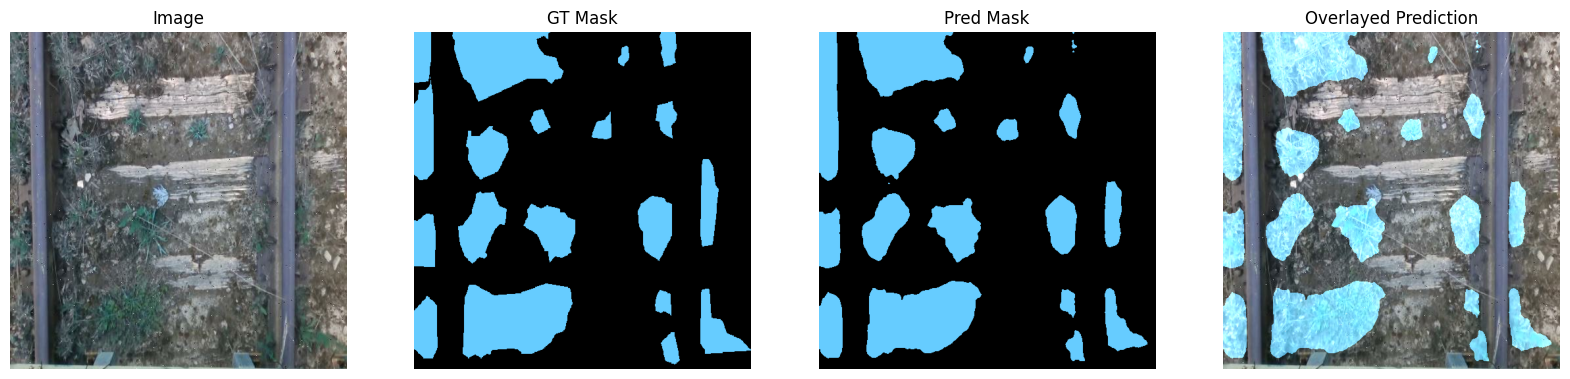

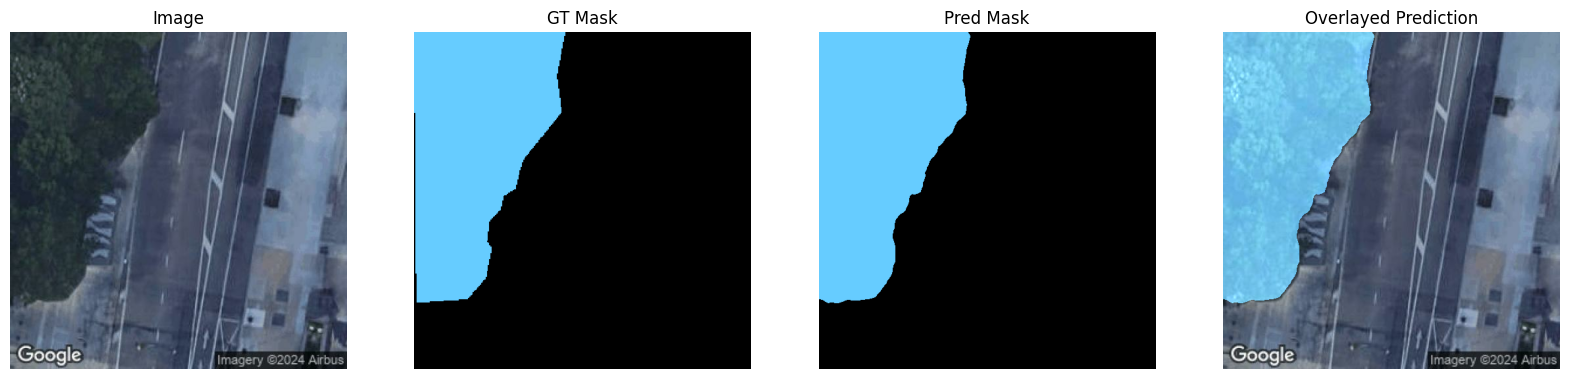

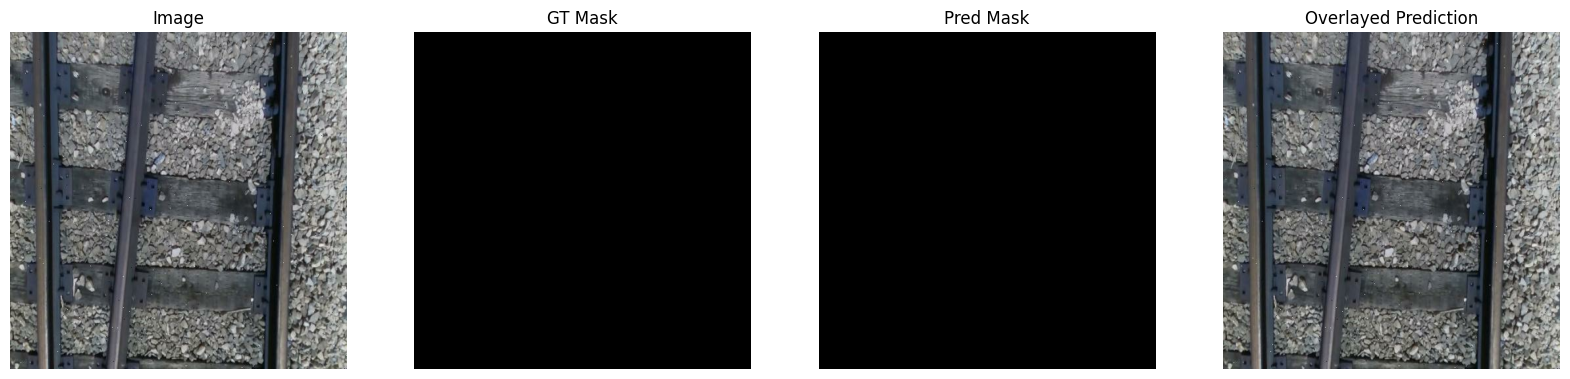

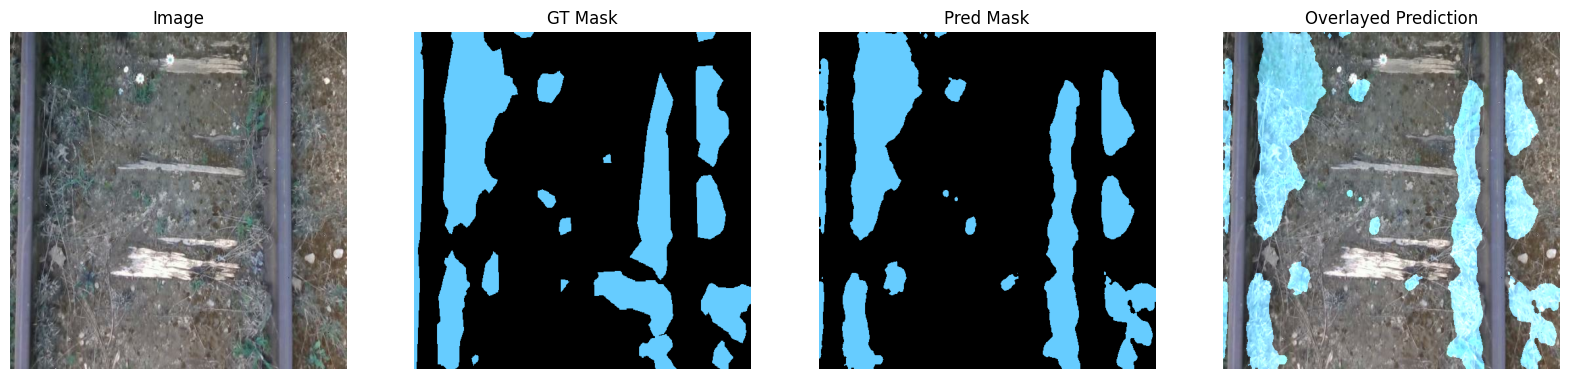

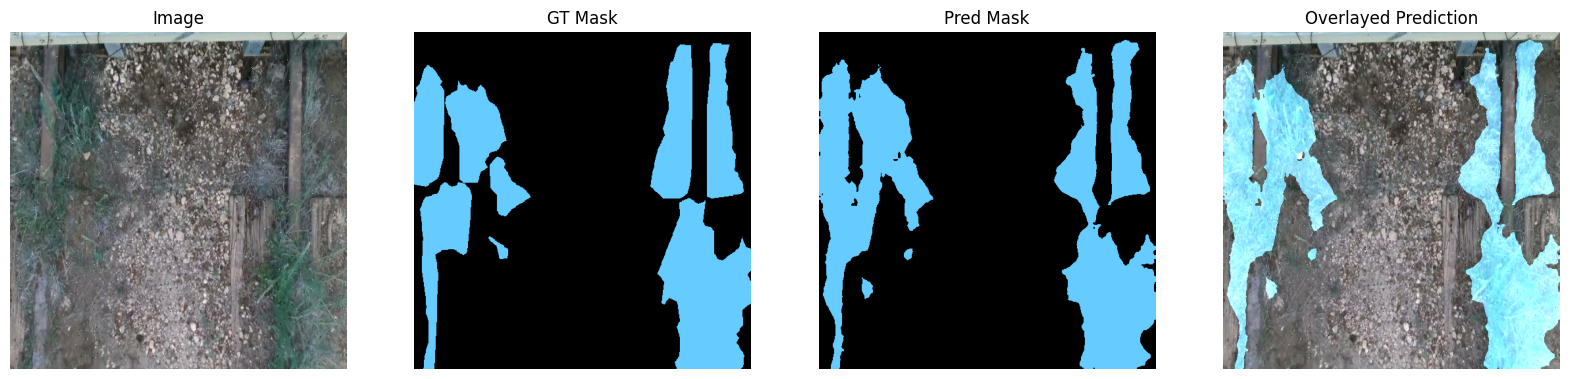

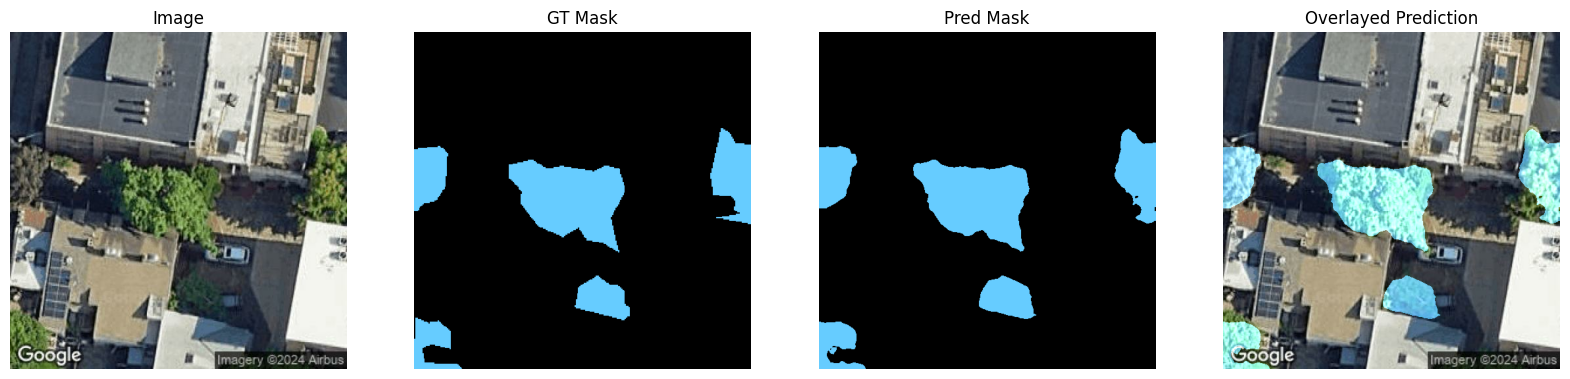

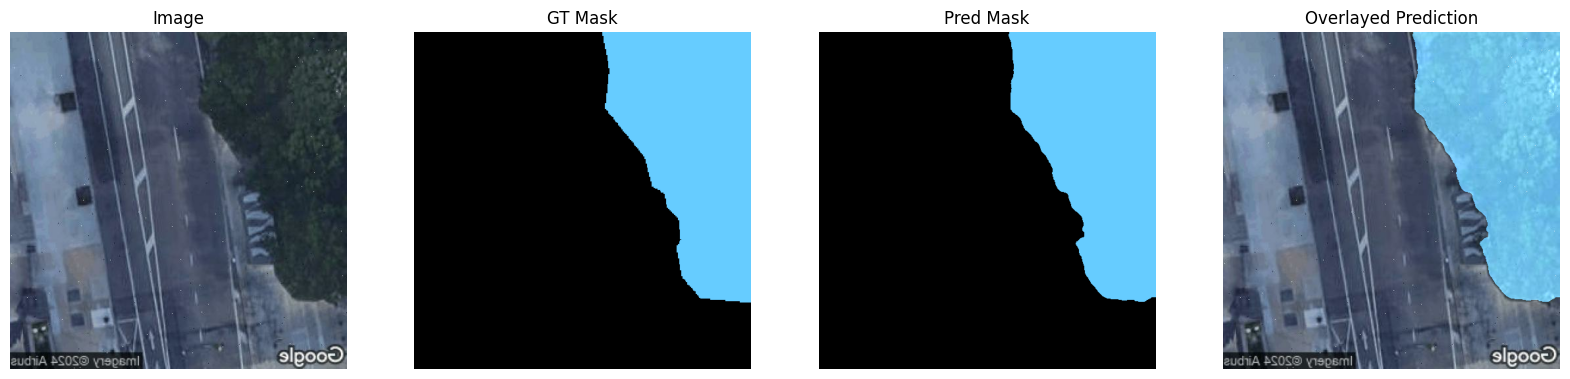

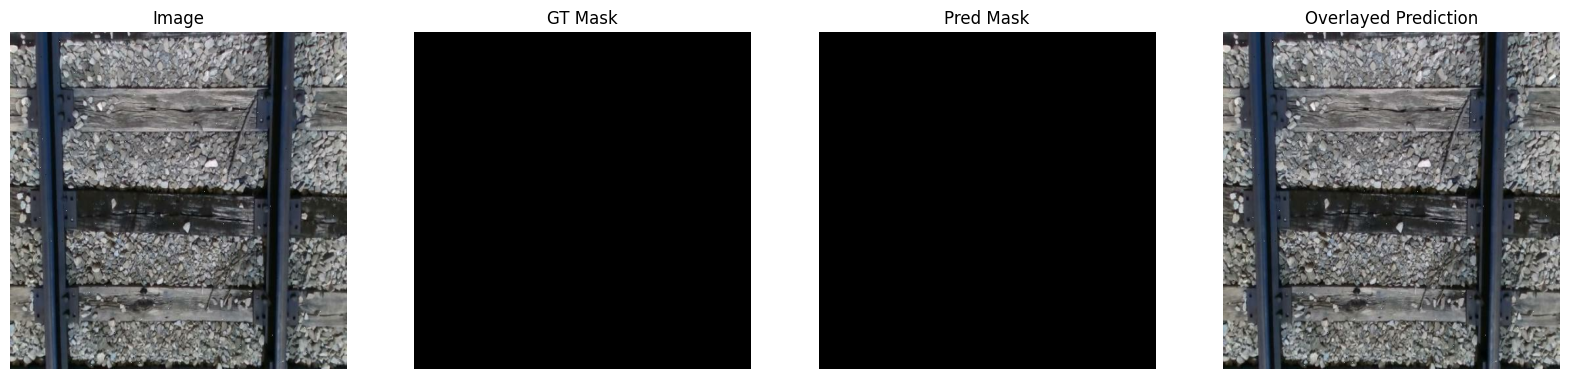

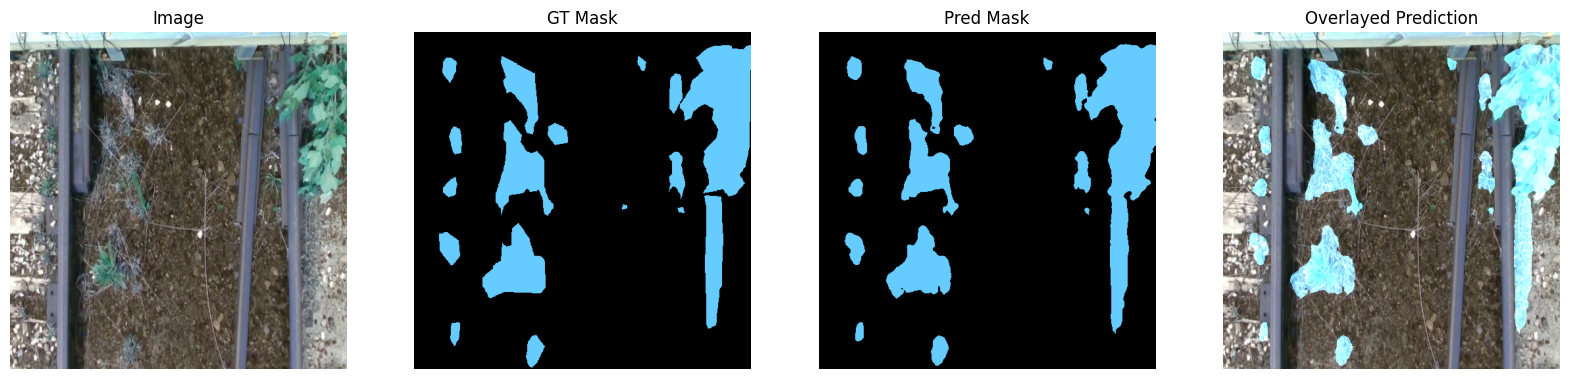

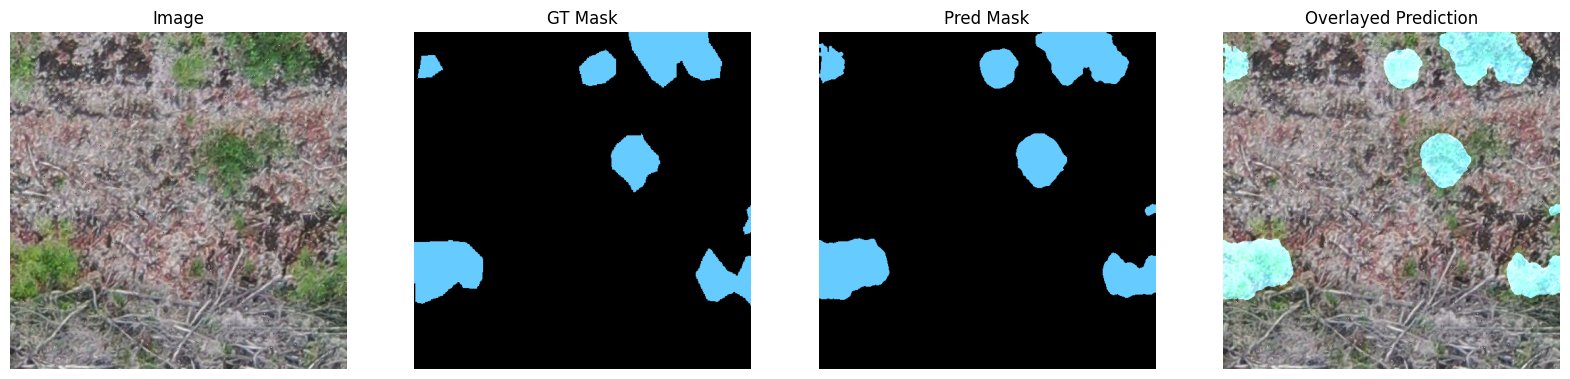

In [ ]:
inference(model, valid_dataset, samples_to_plot=10)